In [3]:
import pandas as pd
import geopandas as gpd
import numpy as np
from pathlib import Path
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

%matplotlib inline

PROJECT_ROOT = Path(r"C:\Users\pande\OneDrive\Documents\Waste management grid")
PROCESSED = PROJECT_ROOT / "data" / "processed"

predictions = pd.read_parquet(PROCESSED / "predictions.parquet")
districts_gdf = gpd.read_file(PROCESSED / "districts.geojson")
print(predictions.shape)

C:\Users\pande\anaconda3\Lib\site-packages\pyogrio\core.py:35: RuntimeWarning: Could not detect GDAL data files. Set GDAL_DATA environment variable to the correct path.
  _init_gdal_data()


(24411, 28)


In [4]:
district_summary = predictions.groupby("BoroCd").agg(
    avg_waste=("predicted_tons", "mean"),
    total_waste=("predicted_tons", "sum"),
    std_waste=("predicted_tons", "std"),
    max_waste=("predicted_tons", "max"),
    min_waste=("predicted_tons", "min"),
).reset_index()

district_summary["cv_waste"] = district_summary["std_waste"] / district_summary["avg_waste"]

print(district_summary.shape)  # should be (59, ...)
district_summary.head()

(59, 7)


,BoroCd,avg_waste,total_waste,std_waste,max_waste,min_waste,cv_waste
0,101,1737.088652,7.243660e+05,530.883261,2360.761930,624.661715,0.305617
1,102,3337.643973,1.391798e+06,372.939650,4260.606562,2482.172492,0.111737
2,103,6128.332995,2.573900e+06,1353.175459,7733.281278,3258.444456,0.220806
3,104,4215.078783,1.757688e+06,632.689160,5343.157925,2039.813207,0.150101
4,105,2172.506741,9.102803e+05,387.064551,2982.914016,1173.912034,0.178165


In [5]:
cluster_features = ["avg_waste", "total_waste", "std_waste", "cv_waste"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(district_summary[cluster_features])

X_scaled_df = pd.DataFrame(X_scaled, columns=cluster_features)
X_scaled_df.describe()

,avg_waste,total_waste,std_waste,cv_waste
count,5.900000e+01,5.900000e+01,5.900000e+01,5.900000e+01
mean,7.790379e-16,1.505387e-17,-3.725833e-16,-9.408670e-19
std,1.008584e+00,1.008584e+00,1.008584e+00,1.008584e+00
min,-2.097533e+00,-2.070434e+00,-1.015062e+00,-9.565763e-01
25%,-8.169354e-01,-8.206487e-01,-5.943658e-01,-5.935916e-01
50%,-1.085643e-01,-7.174222e-02,-3.189256e-01,-3.223036e-01
75%,5.918390e-01,5.459344e-01,2.997666e-01,2.514869e-01
max,2.346807e+00,2.365884e+00,5.201135e+00,5.294709e+00


C:\Users\pande\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\pande\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\pande\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\pande\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

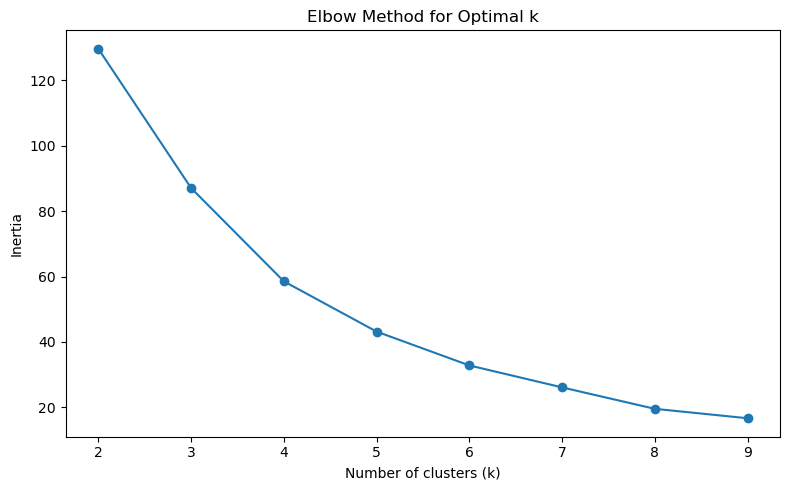

In [6]:
inertias = []
K_range = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.tight_layout()
plt.savefig(PROCESSED / "kmeans_elbow.png", dpi=150)
plt.show()

In [7]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
district_summary["kmeans_cluster"] = kmeans.fit_predict(X_scaled)

# Order clusters by average waste so cluster 0 = lowest, 3 = highest (easier to interpret)
cluster_order = (
    district_summary.groupby("kmeans_cluster")["avg_waste"]
    .mean()
    .sort_values()
    .index
)
remap = {old: new for new, old in enumerate(cluster_order)}
district_summary["kmeans_cluster"] = district_summary["kmeans_cluster"].map(remap)

district_summary.groupby("kmeans_cluster")[["avg_waste", "total_waste", "cv_waste"]].mean()

C:\Users\pande\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,avg_waste,total_waste,cv_waste
kmeans_cluster,,,
0,3367.953566,1.393485e+06,0.129394
1,5191.947733,2.139375e+06,0.092471
2,5792.286611,2.380630e+06,0.537843
3,7051.768443,2.938377e+06,0.163802


In [8]:
# eps and min_samples need tuning — start with these and adjust based on results
dbscan = DBSCAN(eps=0.8, min_samples=3)
district_summary["dbscan_cluster"] = dbscan.fit_predict(X_scaled)

# -1 means DBSCAN flagged it as noise/outlier — i.e., a true anomaly/hotspot
n_outliers = (district_summary["dbscan_cluster"] == -1).sum()
n_clusters = district_summary["dbscan_cluster"].nunique() - (1 if n_outliers > 0 else 0)

print(f"DBSCAN found {n_clusters} clusters and {n_outliers} outlier districts (potential hotspots)")
district_summary[district_summary["dbscan_cluster"] == -1][["BoroCd", "avg_waste", "total_waste", "cv_waste"]]

DBSCAN found 1 clusters and 10 outlier districts (potential hotspots)


,BoroCd,avg_waste,total_waste,cv_waste
0,101,1737.088652,7.243660e+05,0.305617
2,103,6128.332995,2.573900e+06,0.220806
4,105,2172.506741,9.102803e+05,0.178165
9,110,5505.502562,2.306806e+06,0.296414
13,202,5792.286611,2.380630e+06,0.537843
14,203,2197.897974,9.011382e+05,0.101099
17,206,3828.218772,1.584883e+06,0.240742
31,308,5261.033437,2.157024e+06,0.270688
48,407,8703.933625,3.629540e+06,0.165342
57,502,6123.483632,2.584110e+06,0.164501


In [9]:
# Try a small range of eps values to see how outlier count changes
for eps_val in [0.5, 0.6, 0.7, 0.8, 1.0, 1.2, 1.5]:
    db = DBSCAN(eps=eps_val, min_samples=3)
    labels = db.fit_predict(X_scaled)
    n_out = (labels == -1).sum()
    n_clust = len(set(labels)) - (1 if -1 in labels else 0)
    print(f"eps={eps_val}: {n_clust} clusters, {n_out} outliers")

eps=0.5: 1 clusters, 18 outliers
eps=0.6: 2 clusters, 12 outliers
eps=0.7: 1 clusters, 12 outliers
eps=0.8: 1 clusters, 10 outliers
eps=1.0: 1 clusters, 6 outliers
eps=1.2: 1 clusters, 2 outliers
eps=1.5: 1 clusters, 2 outliers


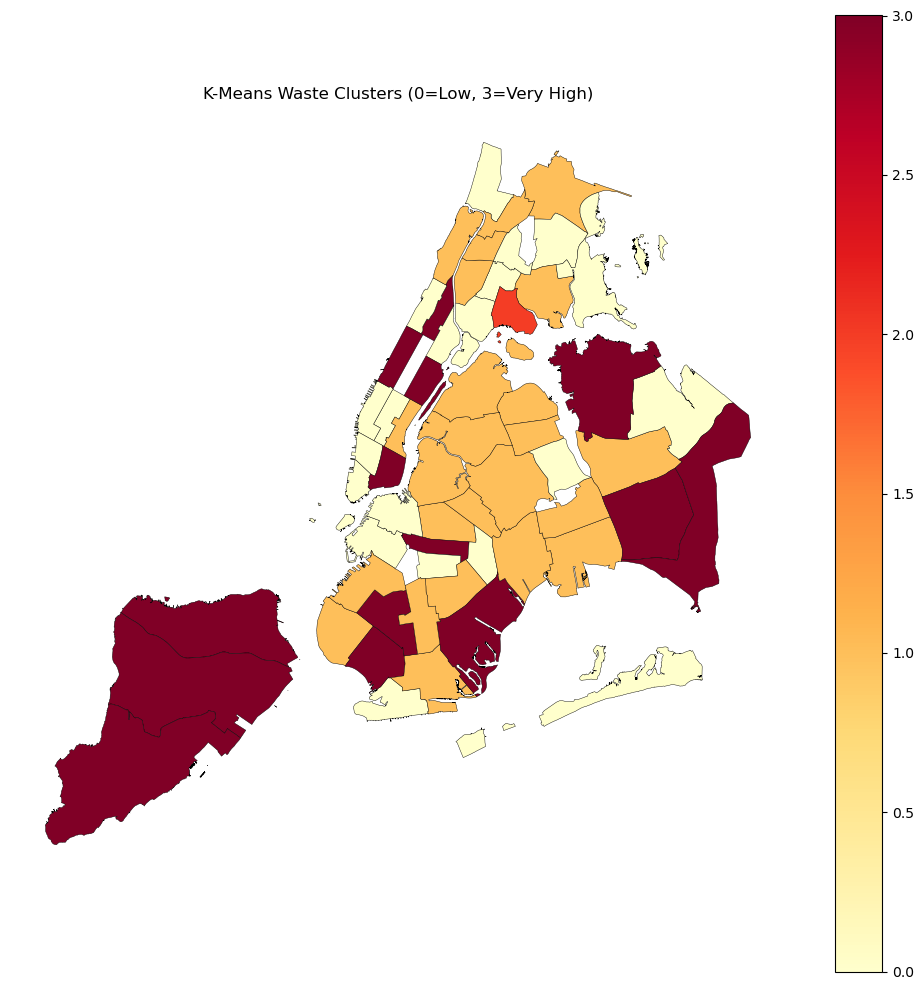

In [10]:
merged = districts_gdf.merge(district_summary, on="BoroCd")

fig, ax = plt.subplots(figsize=(10, 10))
merged.plot(column="kmeans_cluster", cmap="YlOrRd", legend=True, ax=ax, edgecolor="black", linewidth=0.3)
ax.set_title("K-Means Waste Clusters (0=Low, 3=Very High)")
ax.axis("off")
plt.tight_layout()
plt.savefig(PROCESSED / "kmeans_cluster_map.png", dpi=150)
plt.show()

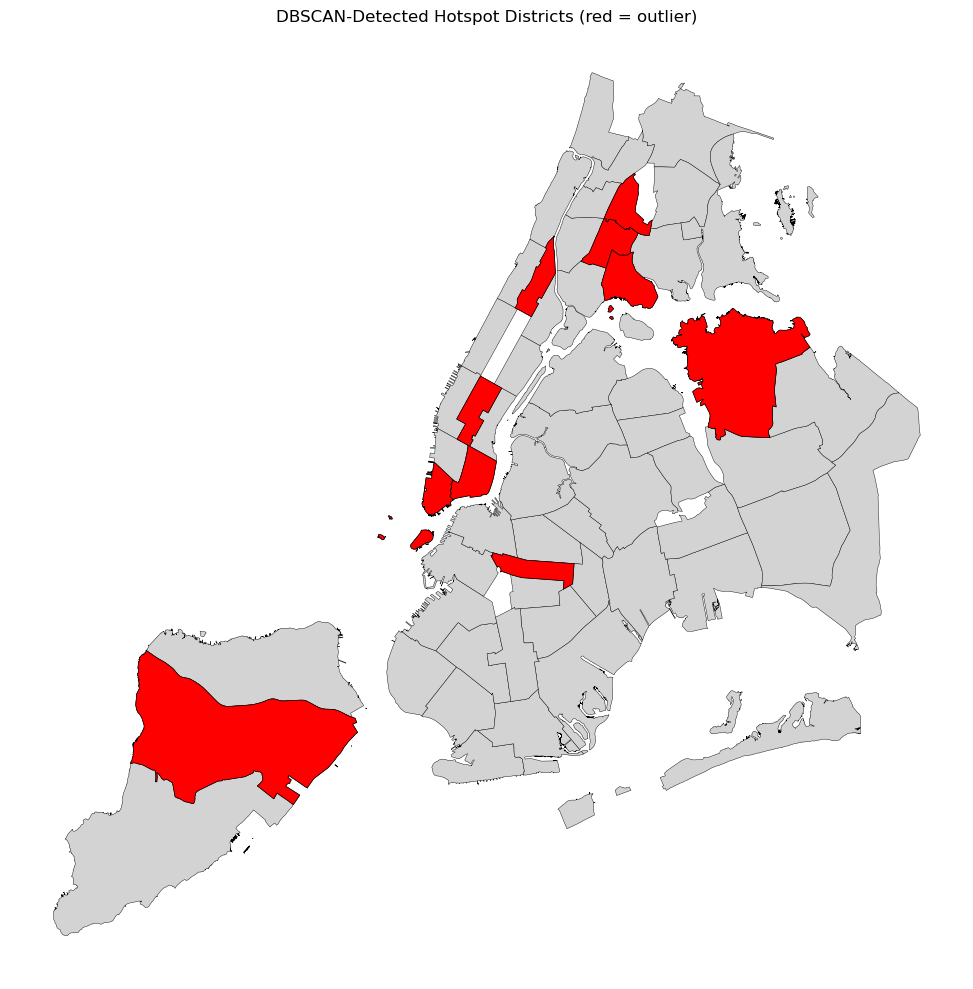

In [11]:
fig, ax = plt.subplots(figsize=(10, 10))
merged.plot(ax=ax, color="lightgrey", edgecolor="black", linewidth=0.3)
merged[merged["dbscan_cluster"] == -1].plot(ax=ax, color="red", edgecolor="black", linewidth=0.5)
ax.set_title("DBSCAN-Detected Hotspot Districts (red = outlier)")
ax.axis("off")
plt.tight_layout()
plt.savefig(PROCESSED / "dbscan_hotspot_map.png", dpi=150)
plt.show()